In [14]:
import os
print(f"Notebook working dir: {os.getcwd()}")
print(f"\nFolders here:")
for item in sorted(os.listdir('.')):
    if os.path.isdir(item):
        print(f"  {item}/")

Notebook working dir: /Users/atharvchaudhary/PERSONAL/Public Projects/rl-beat-generation/notebooks

Folders here:


In [18]:
print(os.path.dirname(os.getcwd()))

/Users/atharvchaudhary/PERSONAL/Public Projects/rl-beat-generation


In [16]:
repo = os.path.dirname(os.getcwd())
save_path = os.path.join(repo, "checkpoints", "discriminator_v1.pt")

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Config — all hyperparameters in one place
CONFIG = {
    "num_instruments": 4,   # Phase 1: kick, snare, hh, clap
    "num_steps": 16,        # 16th notes per bar
    "d_model": 64,          # embedding dimension
    "num_heads": 4,         # attention heads
    "num_blocks": 2,        # encoder blocks
    "d_ff": 256,            # feed-forward hidden dim
    "dropout": 0.1,
    "lr": 3e-4,
    "batch_size": 32,
    "epochs": 30,
    "label_smoothing": 0.1,
}

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Device: {device}")
print(f"Config: {CONFIG}")

Device: mps
Config: {'num_instruments': 4, 'num_steps': 16, 'd_model': 64, 'num_heads': 4, 'num_blocks': 2, 'd_ff': 256, 'dropout': 0.1, 'lr': 0.0003, 'batch_size': 32, 'epochs': 30, 'label_smoothing': 0.1}


### MultiHeadAttention

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_out = nn.Linear(d_model, d_model)
    
    def forward(self, x):
        B, seq_len, _ = x.shape
        
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)
        
        # Split into heads: (B, seq, d_model) → (B, heads, seq, d_k)
        Q = Q.view(B, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(B, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(B, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # Scaled dot-product attention
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_weights = F.softmax(scores, dim=-1)
        
        out = attn_weights @ V
        
        # Concat heads back: (B, heads, seq, d_k) → (B, seq, d_model)
        out = out.transpose(1, 2).contiguous().view(B, seq_len, self.d_model)
        out = self.W_out(out)
        
        return out, attn_weights

# Test
mha = MultiHeadAttention(64, 4)
test = torch.randn(1, 16, 64)
out, w = mha(test)
print(f"In: {test.shape} → Out: {out.shape}, Attn: {w.shape}")

In: torch.Size([1, 16, 64]) → Out: torch.Size([1, 16, 64]), Attn: torch.Size([1, 4, 16, 16])


EncoderBlock

In [4]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        attn_out, attn_weights = self.attention(x)
        x = self.norm1(x + self.dropout(attn_out))
        
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        
        return x, attn_weights

# Test
block = EncoderBlock(64, 4, 256)
out, w = block(test)
print(f"In: {test.shape} → Out: {out.shape}")

In: torch.Size([1, 16, 64]) → Out: torch.Size([1, 16, 64])


BeatDiscriminator

In [5]:
class BeatDiscriminator(nn.Module):
    def __init__(self, num_instruments, num_steps, d_model, num_heads, num_blocks, d_ff, dropout=0.1):
        super().__init__()
        self.num_steps = num_steps
        self.d_model = d_model
        
        self.token_embed = nn.Linear(num_instruments, d_model)
        self.pos_embed = nn.Embedding(num_steps, d_model)
        
        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_blocks)
        ])
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
            nn.Sigmoid(),
        )
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, grid):
        B = grid.shape[0]
        
        # (B, 4, 16) → (B, 16, 4) → (B, 16, 64)
        x = grid.transpose(1, 2)
        x = self.token_embed(x)
        
        # Add positional encoding
        positions = torch.arange(self.num_steps, device=grid.device)
        x = self.dropout(x + self.pos_embed(positions))
        
        # Encoder blocks
        all_attn = []
        for block in self.encoder_blocks:
            x, attn = block(x)
            all_attn.append(attn)
        
        # Mean pool → classify
        x = x.mean(dim=1)
        out = self.classifier(x)
        
        return out, all_attn

# Test
disc = BeatDiscriminator(**{k: CONFIG[k] for k in 
    ["num_instruments", "num_steps", "d_model", "num_heads", "num_blocks", "d_ff", "dropout"]})

total_params = sum(p.numel() for p in disc.parameters())
print(f"Parameters: {total_params:,}")

test_grid = torch.randint(0, 2, (1, 4, 16)).float()
prob, attn = disc(test_grid)
print(f"In: {test_grid.shape} → P(real): {prob.item():.4f}")

Parameters: 103,425
In: torch.Size([1, 4, 16]) → P(real): 0.6059


NegativeGenerator

In [6]:
class NegativeGenerator:
    @staticmethod
    def random_grid(n_inst=4, n_steps=16):
        density = np.random.uniform(0.1, 0.7)
        return (np.random.rand(n_inst, n_steps) < density).astype(np.float32)
    
    @staticmethod
    def shuffled_grid(real_grid):
        grid = real_grid.copy()
        np.random.shuffle(grid)
        return grid
    
    @staticmethod
    def density_wrong_grid(n_inst=4, n_steps=16):
        density = np.random.uniform(0.0, 0.1) if np.random.rand() > 0.5 else np.random.uniform(0.8, 1.0)
        return (np.random.rand(n_inst, n_steps) < density).astype(np.float32)

BeatDataset

In [ ]:
class BeatDataset(Dataset):
    def __init__(self, real_grids, agent_pool=None, num_samples=5000):
        self.real_grids = real_grids
        self.neg_gen = NegativeGenerator()
        self.agent_pool = agent_pool or []
        self.num_samples = num_samples
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        if np.random.rand() < 0.5:
            # Real beat
            i = np.random.randint(len(self.real_grids))
            grid = self.real_grids[i].astype(np.float32)
            label = 1.0
        else:
            # Fake beat
            neg_type = np.random.choice(['random', 'shuffled', 'density', 'agent'],
                                         p=[0.3, 0.3, 0.2, 0.2])
            if neg_type == 'agent' and len(self.agent_pool) > 0:
                grid = self.agent_pool[np.random.randint(len(self.agent_pool))]
            elif neg_type == 'shuffled':
                grid = self.neg_gen.shuffled_grid(self.real_grids[np.random.randint(len(self.real_grids))])
            elif neg_type == 'density':
                grid = self.neg_gen.density_wrong_grid()
            else:
                grid = self.neg_gen.random_grid()
            label = 0.0
        
        return torch.tensor(grid), torch.tensor([label])

generate_synthetic_beats

In [8]:
# === Synthetic real beats (placeholder until Taha's Groove MIDI data) ===
# TODO: Replace with: real_beats = np.load('data/groove_midi_grids.npy')  # (42133, 4, 16)
def generate_synthetic_beats(n=1000):
    grids = []
    for _ in range(n):
        grid = np.zeros((4, 16), dtype=np.float32)
        # Kick
        pattern = np.random.choice(['four', 'synco', 'half'])
        if pattern == 'four':    grid[0, [0, 4, 8, 12]] = 1
        elif pattern == 'synco': grid[0, [0, 6, 10, 12]] = 1
        else:                    grid[0, [0, 8]] = 1
        # Snare
        grid[1, [4, 12]] = 1
        if np.random.rand() > 0.7: grid[1, 10] = 1  # ghost note
        # Hi-hat
        hh = np.random.choice(['8th', '16th', 'off'])
        if hh == '8th':    grid[2, ::2] = 1
        elif hh == '16th': grid[2, :] = 1
        else:              grid[2, 1::2] = 1
        # Clap
        if np.random.rand() > 0.5: grid[3] = grid[1].copy()
        grids.append(grid)
    return np.array(grids)


In [9]:
real_beats = generate_synthetic_beats(1000)
dataset = BeatDataset(real_beats, num_samples=4000)
dataloader = DataLoader(dataset, batch_size=CONFIG["batch_size"], shuffle=True)

grids, labels = next(iter(dataloader))
print(f"Batch — grids: {grids.shape}, labels: {labels.shape}")
print(f"Real in batch: {labels.sum().int().item()} / {len(labels)}")

Batch — grids: torch.Size([32, 4, 16]), labels: torch.Size([32, 1])
Real in batch: 18 / 32


Training Loop

In [10]:
def train_discriminator(disc, dataloader, config, device):
    disc = disc.to(device)
    disc.train()
    
    optimizer = torch.optim.Adam(disc.parameters(), lr=config["lr"], weight_decay=1e-5)
    criterion = nn.BCELoss()
    eps = config["label_smoothing"]
    
    history = {"loss": [], "acc": [], "real_acc": [], "fake_acc": []}
    
    for epoch in range(config["epochs"]):
        total_loss, correct, total = 0, 0, 0
        real_correct, real_total, fake_correct, fake_total = 0, 0, 0, 0
        
        for grids, labels in dataloader:
            grids, labels = grids.to(device), labels.to(device)
            smooth_labels = labels * (1 - eps) + eps / 2
            
            preds, _ = disc(grids)
            loss = criterion(preds, smooth_labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            predicted = (preds > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            real_mask = labels == 1.0
            fake_mask = labels == 0.0
            if real_mask.any():
                real_correct += (predicted[real_mask] == labels[real_mask]).sum().item()
                real_total += real_mask.sum().item()
            if fake_mask.any():
                fake_correct += (predicted[fake_mask] == labels[fake_mask]).sum().item()
                fake_total += fake_mask.sum().item()
        
        n = len(dataloader)
        h = history
        h["loss"].append(total_loss / n)
        h["acc"].append(correct / total)
        h["real_acc"].append(real_correct / max(real_total, 1))
        h["fake_acc"].append(fake_correct / max(fake_total, 1))
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{config['epochs']} | "
                  f"Loss: {h['loss'][-1]:.4f} | "
                  f"Acc: {h['acc'][-1]:.3f} | "
                  f"Real: {h['real_acc'][-1]:.3f} | "
                  f"Fake: {h['fake_acc'][-1]:.3f}")
    
    return history

print("Training function ready.")

Training function ready.


In [11]:
# Fresh discriminator
disc = BeatDiscriminator(**{k: CONFIG[k] for k in 
    ["num_instruments", "num_steps", "d_model", "num_heads", "num_blocks", "d_ff", "dropout"]})

print(f"Training on: {device}")
history = train_discriminator(disc, dataloader, CONFIG, device)

Training on: mps
Epoch   1/30 | Loss: 0.4373 | Acc: 0.890 | Real: 0.932 | Fake: 0.850
Epoch   5/30 | Loss: 0.2342 | Acc: 0.986 | Real: 0.999 | Fake: 0.973
Epoch  10/30 | Loss: 0.2305 | Acc: 0.988 | Real: 1.000 | Fake: 0.975
Epoch  15/30 | Loss: 0.2324 | Acc: 0.987 | Real: 0.999 | Fake: 0.975
Epoch  20/30 | Loss: 0.2382 | Acc: 0.984 | Real: 0.999 | Fake: 0.969
Epoch  25/30 | Loss: 0.2297 | Acc: 0.988 | Real: 1.000 | Fake: 0.975
Epoch  30/30 | Loss: 0.2287 | Acc: 0.989 | Real: 1.000 | Fake: 0.977


Real (four-on-the-floor):  0.9412  ✓
Random noise:              0.0442  ✓
Shuffled rows:             0.0471  ✓


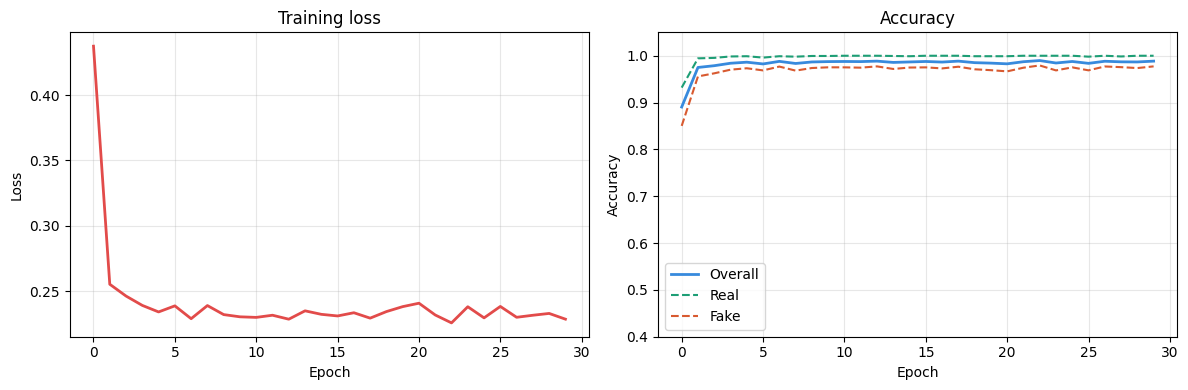

In [12]:
import matplotlib.pyplot as plt

# Test beats
beat_grid = np.array([
    [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
])

disc.eval()
d = next(disc.parameters()).device

real = torch.tensor(beat_grid, dtype=torch.float32).unsqueeze(0).to(d)
fake = (torch.rand(1, 4, 16) > 0.5).float().to(d)
shuffled = torch.tensor(np.random.permutation(beat_grid), dtype=torch.float32).unsqueeze(0).to(d)

with torch.no_grad():
    r, _ = disc(real)
    f, _ = disc(fake)
    s, _ = disc(shuffled)

print(f"Real (four-on-the-floor):  {r.item():.4f}  {'✓' if r.item() > 0.5 else '✗'}")
print(f"Random noise:              {f.item():.4f}  {'✓' if f.item() < 0.5 else '✗'}")
print(f"Shuffled rows:             {s.item():.4f}  {'✓' if s.item() < 0.5 else '✗'}")

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["loss"], color='#E24B4A', linewidth=2)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Training loss')
ax1.grid(True, alpha=0.3)

ax2.plot(history["acc"], color='#378ADD', linewidth=2, label='Overall')
ax2.plot(history["real_acc"], color='#1D9E75', linewidth=1.5, linestyle='--', label='Real')
ax2.plot(history["fake_acc"], color='#D85A30', linewidth=1.5, linestyle='--', label='Fake')
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy', ylim=(0.4, 1.05))
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
torch.save(disc.state_dict(), save_path)
print(f"Saved: {save_path}")

# Verify reload
disc_test = BeatDiscriminator(**{k: CONFIG[k] for k in 
    ["num_instruments", "num_steps", "d_model", "num_heads", "num_blocks", "d_ff", "dropout"]})
disc_test.load_state_dict(torch.load(save_path, weights_only=True))
disc_test.eval()

with torch.no_grad():
    prob, _ = disc_test(torch.tensor(beat_grid, dtype=torch.float32).unsqueeze(0))
    print(f"Reload check — P(real): {prob.item():.4f} (should match {r.item():.4f})")

Saved: /Users/atharvchaudhary/PERSONAL/Public Projects/rl-beat-generation/checkpoints/discriminator_v1.pt
Reload check — P(real): 0.9412 (should match 0.9412)


In [20]:
# Test importing from the module
import sys
sys.path.insert(0, repo)

from models.discriminator import BeatDiscriminator, NegativeGenerator, BeatDataset

# Load saved weights
disc_from_module = BeatDiscriminator(**{k: CONFIG[k] for k in 
    ["num_instruments", "num_steps", "d_model", "num_heads", "num_blocks", "d_ff", "dropout"]})
disc_from_module.load_state_dict(torch.load(save_path, weights_only=True))
disc_from_module.eval()

with torch.no_grad():
    prob, _ = disc_from_module(torch.tensor(beat_grid, dtype=torch.float32).unsqueeze(0))
    print(f"Import + load check — P(real): {prob.item():.4f} ✓")

Import + load check — P(real): 0.9412 ✓
